In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# pd.set_option('display.max_rows',None)

In [4]:
Tdata = pd.read_csv("Navi_data.csv")
Tdata

,ID,Date,Time,Longitude,Latitude,Speed
0,502915,20171209,122533,126.888421,37.510334,0.000000
1,502915,20171209,122635,126.888421,37.510334,0.000000
2,502915,20171209,122738,126.888874,37.510986,4.730095
3,502915,20171209,122943,126.886946,37.512514,6.924282
4,502915,20171209,123045,126.882310,37.514892,28.306628
...,...,...,...,...,...,...
1038365,3103978,20171222,235512,127.275210,38.087225,0.000000
1038366,3103978,20171222,235612,127.275210,38.087225,0.000000
1038367,3103978,20171222,235713,127.275210,38.087225,0.000000
1038368,3103978,20171222,235813,127.275210,38.087225,0.000000


# __Navi_data 가공__

In [5]:
import pandas as pd

Tdata = pd.read_csv("Navi_data.csv")

all_trips = pd.DataFrame()

unique_ids = Tdata.ID.unique()

# 반복수행

for unique_id in unique_ids:
    MyT = Tdata[Tdata.ID == unique_id]

    MyT['Time_hh'] = MyT.Time // 10000
    MyT['Time_mm'] = (MyT.Time // 100) - (MyT.Time_hh * 100)
    MyT['Time_ss'] = MyT.Time - (MyT.Time_hh * 10000) - (MyT.Time_mm * 100)
    MyT['Time_H'] = MyT.Time_hh + (MyT.Time_mm / 60) + (MyT.Time_ss / 3600)

    MyT['TripID'] = 0
    MyT['TripOD'] = 0

    MyT.TripID.iloc[0] = 1
    MyT.TripOD.iloc[0] = 'origin'
    MyT.TripOD.iloc[len(MyT) - 1] = 'destination'

    for n in range(1, len(MyT)):
        if MyT.Date.iloc[n] == MyT.Date.iloc[n - 1]:
            if (MyT.Time_H.iloc[n] - MyT.Time_H.iloc[n - 1]) > 0.1667:
                MyT.TripID.iloc[n] = MyT.TripID.iloc[n - 1] + 1
                MyT.TripOD.iloc[n] = "origin"
                MyT.TripOD.iloc[n - 1] = "destination"
            else:
                MyT.TripID.iloc[n] = MyT.TripID.iloc[n - 1]
        else:
            MyT.TripID.iloc[n] = 1
            MyT.TripOD.iloc[n] = "origin"
            MyT.TripOD.iloc[n - 1] = "destination"

    MyT_Trip = MyT.loc[:, ['ID', 'Date', 'TripID']]
    MyT_Trip = MyT_Trip.drop_duplicates()

    MyT_Trip['Longitude_O'] = 0
    MyT_Trip['Latitude_O'] = 0
    MyT_Trip['Time_H_O'] = 0

    MyT_Trip['Longitude_D'] = 0
    MyT_Trip['Latitude_D'] = 0
    MyT_Trip['Time_H_D'] = 0

    MyT_Trip['T_time'] = 0

    m = 0
    for n in range(0, len(MyT)):
        if (MyT.Date.iloc[n] == MyT_Trip.Date.iloc[m]) & (MyT.TripID.iloc[n] == MyT_Trip.TripID.iloc[m]):
            if MyT.TripOD.iloc[n] == "origin":
                MyT_Trip.Longitude_O.iloc[m] = MyT.Longitude.iloc[n]
                MyT_Trip.Latitude_O.iloc[m] = MyT.Latitude.iloc[n]
                MyT_Trip.Time_H_O.iloc[m] = MyT.Time_H.iloc[n]
            elif MyT.TripOD.iloc[n] == "destination":
                MyT_Trip.Longitude_D.iloc[m] = MyT.Longitude.iloc[n]
                MyT_Trip.Latitude_D.iloc[m] = MyT.Latitude.iloc[n]
                MyT_Trip.Time_H_D.iloc[m] = MyT.Time_H.iloc[n]

                MyT_Trip.T_time.iloc[m] = (MyT_Trip.Time_H_D.iloc[m] - MyT_Trip.Time_H_O.iloc[m]) * 60
                m = m + 1

    
    all_trips = pd.concat([all_trips, MyT_Trip], ignore_index=True)


# all_trips.to_csv("AllTrips.csv", index=False)

all_trips

,ID,Date,TripID,Longitude_O,Latitude_O,Time_H_O,Longitude_D,Latitude_D,Time_H_D,T_time
0,502915,20171209,1,126.888421,37.510334,12.425833,126.853681,37.527005,12.979167,33.200000
1,502915,20171209,2,126.853612,37.526708,18.477222,126.887373,37.509903,18.878333,24.066667
2,567810,20171209,1,126.759338,37.893490,14.844722,127.003283,37.581771,16.812778,118.083333
3,567810,20171209,2,127.003075,37.579635,19.860278,126.760288,37.894524,21.171111,78.650000
4,600415,20171223,1,127.276707,38.092911,15.976944,127.054269,37.891739,16.906944,55.800000
...,...,...,...,...,...,...,...,...,...,...
12988,3103978,20171219,1,127.274871,38.087522,0.008056,127.266132,38.091824,1.348889,80.450000
12989,3103978,20171219,2,127.265652,38.091947,1.857778,127.274710,38.087183,23.983333,1327.533333
12990,3103978,20171222,1,127.274704,38.086972,0.005833,127.275152,38.087544,17.044444,1022.316667
12991,3103978,20171222,2,127.275152,38.087544,17.995556,127.275152,38.087544,18.132500,8.216667


#### 결측치 확인

In [6]:
all_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12993 entries, 0 to 12992
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           12993 non-null  int64  
 1   Date         12993 non-null  int64  
 2   TripID       12993 non-null  int64  
 3   Longitude_O  12993 non-null  float64
 4   Latitude_O   12993 non-null  float64
 5   Time_H_O     12993 non-null  float64
 6   Longitude_D  12993 non-null  float64
 7   Latitude_D   12993 non-null  float64
 8   Time_H_D     12993 non-null  float64
 9   T_time       12993 non-null  float64
dtypes: float64(7), int64(3)
memory usage: 1015.2 KB


In [7]:
len(all_trips.ID.unique())

216

### __이상치 확인__

하나의 예시 vehicle(ID=2221438)에 대해 조건이 되는 알고리즘을 적용시켜 가공한 파일을 확인한 결과, 이상치가 존재함을 확인하였다. (ex. 위도 = 0)

In [8]:
Tdata = pd.read_csv("Navi_data.csv")
MyT = Tdata[Tdata.ID==2221438]

MyT['Time_hh'] = MyT.Time//10000
MyT['Time_mm'] = (MyT.Time//100)-(MyT.Time_hh*100)
MyT['Time_ss'] = MyT.Time-(MyT.Time_hh*10000)-(MyT.Time_mm*100)
MyT['Time_H']=MyT.Time_hh+(MyT.Time_mm/60)+(MyT.Time_ss/3600)

# Set-up and initialization
MyT['TripID']=0
MyT['TripOD']=0

MyT.TripID.iloc[0]=1 # ".iloc"는 pandas에서 제공하는 함수로 정수를 사용하여 행을 지정(색인, 호출)할 수 있도록 함
MyT.TripOD.iloc[0]='origin'
MyT.TripOD.iloc[len(MyT)-1]='destination' # 마지막 point는 destination, "-1"을 한 것은 첫행이 0이기 때문

for n in range(1,len(MyT)): # 첫번째 data skip
    if MyT.Date.iloc[n]==MyT.Date.iloc[n-1]:
        if (MyT.Time_H.iloc[n]-MyT.Time_H.iloc[n-1])>0.1667:
            MyT.TripID.iloc[n]=MyT.TripID.iloc[n-1]+1
            MyT.TripOD.iloc[n]="origin"
            MyT.TripOD.iloc[n-1]="destination"
        else:
            MyT.TripID.iloc[n]=MyT.TripID.iloc[n-1]
    else:
        MyT.TripID.iloc[n]=1
        MyT.TripOD.iloc[n]="origin"
        MyT.TripOD.iloc[n-1]="destination"

# Create base data frame
MyT_Trip = MyT.loc[:,['ID','Date','TripID']]
MyT_Trip = MyT_Trip.drop_duplicates() #중복된 행 제거

# Create columns
MyT_Trip['Longitude_O']=0
MyT_Trip['Latitude_O']=0
MyT_Trip['Time_H_O']=0

MyT_Trip['Longitude_D']=0
MyT_Trip['Latitude_D']=0
MyT_Trip['Time_H_D']=0

MyT_Trip['T_time']=0

# Complete the table
m = 0
for n in range(0,len(MyT)):
    if (MyT.Date.iloc[n]==MyT_Trip.Date.iloc[m]) & (MyT.TripID.iloc[n]==MyT_Trip.TripID.iloc[m]):
        if MyT.TripOD.iloc[n]=="origin":
            MyT_Trip.Longitude_O.iloc[m]=MyT.Longitude.iloc[n]
            MyT_Trip.Latitude_O.iloc[m]=MyT.Latitude.iloc[n]
            MyT_Trip.Time_H_O.iloc[m]=MyT.Time_H.iloc[n]
        elif MyT.TripOD.iloc[n]=="destination":
            MyT_Trip.Longitude_D.iloc[m]=MyT.Longitude.iloc[n]
            MyT_Trip.Latitude_D.iloc[m]=MyT.Latitude.iloc[n]
            MyT_Trip.Time_H_D.iloc[m]=MyT.Time_H.iloc[n]
            
            MyT_Trip.T_time.iloc[m]=(MyT_Trip.Time_H_D.iloc[m]-MyT_Trip.Time_H_O.iloc[m])*60
            m = m+1
                    

# MyT_Trip.to_csv("MyT_Trip_2221438.csv",index=False)

MyT_Trip

,ID,Date,TripID,Longitude_O,Latitude_O,Time_H_O,Longitude_D,Latitude_D,Time_H_D,T_time
223517,2221438,20171201,1,0.000000,0.000000,0.000000,127.250372,38.157841,5.812500,348.750000
223518,2221438,20171201,2,127.250372,38.157841,9.272500,127.250375,38.157841,13.346944,244.466667
223745,2221438,20171201,3,127.250375,38.157841,13.928333,127.250375,38.157841,14.029444,6.066667
223750,2221438,20171201,4,127.250375,38.157841,17.001667,127.250811,38.157610,22.013611,300.716667
224010,2221438,20171201,5,127.250811,38.157610,22.709722,127.250495,38.157780,23.983333,76.416667
...,...,...,...,...,...,...,...,...,...,...
237307,2221438,20171231,2,0.000000,0.000000,0.000000,127.250350,38.157855,11.583889,695.033333
237308,2221438,20171231,3,127.250395,38.157830,12.227778,127.250617,38.157716,19.436944,432.550000
237675,2221438,20171231,4,0.000000,0.000000,0.000000,127.250617,38.157716,20.076944,1204.616667
237676,2221438,20171231,5,0.000000,0.000000,0.000000,127.250617,38.157716,20.367222,1222.033333


#### all_trips(전체 vehicle 가공 데이터)의 이상치 확인

In [6]:
# Longitude_O 및 Longitude_D 값이 125 이상 130 이하인지 확인
longitude_O_within_range = (all_trips['Longitude_O'] >= 125) & (all_trips['Longitude_O'] <= 130)
longitude_D_within_range = (all_trips['Longitude_D'] >= 125) & (all_trips['Longitude_D'] <= 130)

# 두 조건이 모두 참인지 확인
all_within_range = longitude_O_within_range.all() and longitude_D_within_range.all()

if all_within_range:
    print("모든 Longitude_O 및 Longitude_D 값이 125 이상 130 이하입니다.")
else:
    print("일부 Longitude_O 또는 Longitude_D 값이 125 미만 또는 130 초과입니다.")

일부 Longitude_O 또는 Longitude_D 값이 125 미만 또는 130 초과입니다.


In [7]:
# 이상치인 행들 필터링
out_of_range = all_trips[
    (all_trips['Longitude_O'] < 125) | (all_trips['Longitude_O'] > 130) |
    (all_trips['Longitude_D'] < 125) | (all_trips['Longitude_D'] > 130) |
    (all_trips['Latitude_O'] < 35) | (all_trips['Latitude_O'] > 40) |
    (all_trips['Latitude_O'] < 35) | (all_trips['Latitude_O'] > 40) |
    (all_trips['Time_H_O'] < 0) | (all_trips['Time_H_D'] <= 0) |
    (all_trips['T_time'] <= 0) | (all_trips['T_time']>180) | (all_trips['T_time']<5) ]

print(out_of_range.ID.unique())
print(len(out_of_range.ID.unique()))

[1354799 1395688 1446805 1586316 1618082 1708409 1754540 1766694 1873223
 1994596 1998496 2028833 2036354 2094182 2220702 2220788 2220948 2220984
 2221027 2221068 2221096 2221159 2221177 2221188 2221270 2221299 2221321
 2221349 2221418 2221438 2221487 2221516 2221532 2221590 2221626 2221628
 2221666 2221716 2221789 2221800 2221823 2221927 2221941 2222149 2222223
 2222226 2222230 2222250 2222311 2222327 2222450 2222490 2222512 2222550
 2222579 2222610 2222622 2222640 2222727 2222872 2223020 2223092 2223109
 2223262 2223289 2223379 2223422 2223444 2223457 2223511 2223549 2223624
 2223682 2223702 2223991 2224343 2224633 2224755 2224789 2224820 2224918
 2225012 2225072 2225131 2225562 2225887 2225944 2226565 2227453 2227753
 2227789 2228043 2228249 2228387 2229128 2229133 2229521 2229590 2229717
 2230559 2235079 2238669 2239977 2264056 2290737 2291063 2292580 2294121
 2295977 2349362 2349495 2350231 2361644 2382811 2412671 2472017 2473351
 2474083 2476743 2476829 2483525 2485625 2486325 24

In [8]:
NaviData = all_trips.drop(out_of_range.index)

print(len(NaviData.ID.unique()))

210


최종 210대

'Navi_data'로 생성한 통행 데이터: NaviData

In [9]:
NaviData

,ID,Date,TripID,Longitude_O,Latitude_O,Time_H_O,Longitude_D,Latitude_D,Time_H_D,T_time
0,502915,20171209,1,126.888421,37.510334,12.425833,126.853681,37.527005,12.979167,33.200000
1,502915,20171209,2,126.853612,37.526708,18.477222,126.887373,37.509903,18.878333,24.066667
2,567810,20171209,1,126.759338,37.893490,14.844722,127.003283,37.581771,16.812778,118.083333
3,567810,20171209,2,127.003075,37.579635,19.860278,126.760288,37.894524,21.171111,78.650000
4,600415,20171223,1,127.276707,38.092911,15.976944,127.054269,37.891739,16.906944,55.800000
...,...,...,...,...,...,...,...,...,...,...
12982,3088962,20171211,4,127.079313,37.794664,14.550833,127.040097,37.907772,14.688056,8.233333
12984,3095826,20171228,1,127.351348,37.885981,8.930278,127.351503,37.885670,9.024722,5.666667
12987,3103978,20171217,3,127.275154,38.087547,21.260000,127.275154,38.087547,23.993333,164.000000
12988,3103978,20171219,1,127.274871,38.087522,0.008056,127.266132,38.091824,1.348889,80.450000


In [10]:
NaviData.to_csv("NaviData.csv",index=False)

#### 이상치 설정 이유

출발/도착 위도/경도가 0이 나온 이유:
- MyT까지 가공하여 만들었을 때, TripOD열에서 origin, destination이 이상하게 배정되는 것을 확인하였다.
- 이로 인한 영향으로 생각된다.
- 어떤 vehicle에 대해서는 잘 배정되지만, 어떤 vehicle 통행에서는 알고리즘이 부적절하게 적용되는 것을 확인할 수 있다.

1) 잘 작동한 예시 (ID=2028833)

In [11]:
Tdata = pd.read_csv("Navi_data.csv")
MyT = Tdata[Tdata.ID==2028833]

MyT['Time_hh'] = MyT.Time//10000
MyT['Time_mm'] = (MyT.Time//100)-(MyT.Time_hh*100)
MyT['Time_ss'] = MyT.Time-(MyT.Time_hh*10000)-(MyT.Time_mm*100)
MyT['Time_H']=MyT.Time_hh+(MyT.Time_mm/60)+(MyT.Time_ss/3600)

# Set-up and initialization
MyT['TripID']=0
MyT['TripOD']=0

MyT.TripID.iloc[0]=1 # ".iloc"는 pandas에서 제공하는 함수로 정수를 사용하여 행을 지정(색인, 호출)할 수 있도록 함
MyT.TripOD.iloc[0]='origin'
MyT.TripOD.iloc[len(MyT)-1]='destination' # 마지막 point는 destination, "-1"을 한 것은 첫행이 0이기 때문

for n in range(1,len(MyT)): # 첫번째 data skip
    if MyT.Date.iloc[n]==MyT.Date.iloc[n-1]:
        if (MyT.Time_H.iloc[n]-MyT.Time_H.iloc[n-1])>0.1667:
            MyT.TripID.iloc[n]=MyT.TripID.iloc[n-1]+1
            MyT.TripOD.iloc[n]="origin"
            MyT.TripOD.iloc[n-1]="destination"
        else:
            MyT.TripID.iloc[n]=MyT.TripID.iloc[n-1]
    else:
        MyT.TripID.iloc[n]=1
        MyT.TripOD.iloc[n]="origin"
        MyT.TripOD.iloc[n-1]="destination"

MyT

,ID,Date,Time,Longitude,Latitude,Speed,Time_hh,Time_mm,Time_ss,Time_H,TripID,TripOD
27660,2028833,20171206,51050,127.055283,37.896889,0.261370,5,10,50,5.180556,1,origin
27661,2028833,20171206,51215,127.055286,37.896944,0.261370,5,12,15,5.204167,1,0
27662,2028833,20171206,51401,127.055286,37.896944,0.000000,5,14,1,5.233611,1,0
27663,2028833,20171206,51543,127.055286,37.896944,0.000000,5,15,43,5.261944,1,0
27664,2028833,20171206,51720,127.055286,37.896944,0.000000,5,17,20,5.288889,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
28165,2028833,20171228,135206,127.060428,37.869108,6.023972,13,52,6,13.868333,4,0
28166,2028833,20171228,135317,127.057142,37.876977,46.651369,13,53,17,13.888056,4,0
28167,2028833,20171228,135439,127.056639,37.888516,56.261534,13,54,39,13.910833,4,0
28168,2028833,20171228,135548,127.056008,37.892644,24.078523,13,55,48,13.930000,4,0


2) 잘 작동하지 않은 예시 (ID=2221438)

In [12]:
Tdata = pd.read_csv("Navi_data.csv")
MyT = Tdata[Tdata.ID==2221438]

MyT['Time_hh'] = MyT.Time//10000
MyT['Time_mm'] = (MyT.Time//100)-(MyT.Time_hh*100)
MyT['Time_ss'] = MyT.Time-(MyT.Time_hh*10000)-(MyT.Time_mm*100)
MyT['Time_H']=MyT.Time_hh+(MyT.Time_mm/60)+(MyT.Time_ss/3600)

# Set-up and initialization
MyT['TripID']=0
MyT['TripOD']=0

MyT.TripID.iloc[0]=1 # ".iloc"는 pandas에서 제공하는 함수로 정수를 사용하여 행을 지정(색인, 호출)할 수 있도록 함
MyT.TripOD.iloc[0]='origin'
MyT.TripOD.iloc[len(MyT)-1]='destination' # 마지막 point는 destination, "-1"을 한 것은 첫행이 0이기 때문

for n in range(1,len(MyT)): # 첫번째 data skip
    if MyT.Date.iloc[n]==MyT.Date.iloc[n-1]:
        if (MyT.Time_H.iloc[n]-MyT.Time_H.iloc[n-1])>0.1667:
            MyT.TripID.iloc[n]=MyT.TripID.iloc[n-1]+1
            MyT.TripOD.iloc[n]="origin"
            MyT.TripOD.iloc[n-1]="destination"
        else:
            MyT.TripID.iloc[n]=MyT.TripID.iloc[n-1]
    else:
        MyT.TripID.iloc[n]=1
        MyT.TripOD.iloc[n]="origin"
        MyT.TripOD.iloc[n-1]="destination"

# MyT.to_csv("MyT_2221438.csv",index=False)

MyT

,ID,Date,Time,Longitude,Latitude,Speed,Time_hh,Time_mm,Time_ss,Time_H,TripID,TripOD
223517,2221438,20171201,54845,127.250372,38.157841,0.0,5,48,45,5.812500,1,destination
223518,2221438,20171201,91621,127.250372,38.157841,0.0,9,16,21,9.272500,2,origin
223519,2221438,20171201,91828,127.250372,38.157841,0.0,9,18,28,9.307778,2,0
223520,2221438,20171201,91931,127.250372,38.157841,0.0,9,19,31,9.325278,2,0
223521,2221438,20171201,92031,127.250372,38.157841,0.0,9,20,31,9.341944,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
237673,2221438,20171231,192513,127.250617,38.157716,0.0,19,25,13,19.420278,3,0
237674,2221438,20171231,192613,127.250617,38.157716,0.0,19,26,13,19.436944,3,destination
237675,2221438,20171231,200437,127.250617,38.157716,0.0,20,4,37,20.076944,4,destination
237676,2221438,20171231,202202,127.250617,38.157716,0.0,20,22,2,20.367222,5,destination


기존 알고리즘으로 가공하라는 과제 안내에 따라 수업시간에 다룬 코드를 사용하였고, 이로 인해 발생한 결측값을 이상치로 간주하였다.

## Geo-coding

In [13]:
import geopandas as gpd

In [14]:
### MyT_Trip의 통행별 출발지 좌표를 이용하여 출발지 GeoDataFrame 생성
NaviData_O = gpd.GeoDataFrame(NaviData, geometry=gpd.points_from_xy(NaviData.Longitude_O, NaviData.Latitude_O))

# Coordinate Reference Systems (CRS)
NaviData_O.crs = {'init': 'epsg:4326'}

NaviData_O

,ID,Date,TripID,Longitude_O,Latitude_O,Time_H_O,Longitude_D,Latitude_D,Time_H_D,T_time,geometry
0,502915,20171209,1,126.888421,37.510334,12.425833,126.853681,37.527005,12.979167,33.200000,POINT (126.88842 37.51033)
1,502915,20171209,2,126.853612,37.526708,18.477222,126.887373,37.509903,18.878333,24.066667,POINT (126.85361 37.52671)
2,567810,20171209,1,126.759338,37.893490,14.844722,127.003283,37.581771,16.812778,118.083333,POINT (126.75934 37.89349)
3,567810,20171209,2,127.003075,37.579635,19.860278,126.760288,37.894524,21.171111,78.650000,POINT (127.00308 37.57964)
4,600415,20171223,1,127.276707,38.092911,15.976944,127.054269,37.891739,16.906944,55.800000,POINT (127.27671 38.09291)
...,...,...,...,...,...,...,...,...,...,...,...
12982,3088962,20171211,4,127.079313,37.794664,14.550833,127.040097,37.907772,14.688056,8.233333,POINT (127.07931 37.79466)
12984,3095826,20171228,1,127.351348,37.885981,8.930278,127.351503,37.885670,9.024722,5.666667,POINT (127.35135 37.88598)
12987,3103978,20171217,3,127.275154,38.087547,21.260000,127.275154,38.087547,23.993333,164.000000,POINT (127.27515 38.08755)
12988,3103978,20171219,1,127.274871,38.087522,0.008056,127.266132,38.091824,1.348889,80.450000,POINT (127.27487 38.08752)


In [15]:
### MyT_Trip의 통행별 도착지 좌표를 이용하여 도착지 GeoDataFrame 생성
NaviData_D = gpd.GeoDataFrame(NaviData, geometry=gpd.points_from_xy(NaviData.Longitude_D, NaviData.Latitude_D))

# Coordinate Reference Systems (CRS)
NaviData_D.crs = {'init': 'epsg:4326'}

NaviData_D

,ID,Date,TripID,Longitude_O,Latitude_O,Time_H_O,Longitude_D,Latitude_D,Time_H_D,T_time,geometry
0,502915,20171209,1,126.888421,37.510334,12.425833,126.853681,37.527005,12.979167,33.200000,POINT (126.85368 37.52701)
1,502915,20171209,2,126.853612,37.526708,18.477222,126.887373,37.509903,18.878333,24.066667,POINT (126.88737 37.50990)
2,567810,20171209,1,126.759338,37.893490,14.844722,127.003283,37.581771,16.812778,118.083333,POINT (127.00328 37.58177)
3,567810,20171209,2,127.003075,37.579635,19.860278,126.760288,37.894524,21.171111,78.650000,POINT (126.76029 37.89452)
4,600415,20171223,1,127.276707,38.092911,15.976944,127.054269,37.891739,16.906944,55.800000,POINT (127.05427 37.89174)
...,...,...,...,...,...,...,...,...,...,...,...
12982,3088962,20171211,4,127.079313,37.794664,14.550833,127.040097,37.907772,14.688056,8.233333,POINT (127.04010 37.90777)
12984,3095826,20171228,1,127.351348,37.885981,8.930278,127.351503,37.885670,9.024722,5.666667,POINT (127.35150 37.88567)
12987,3103978,20171217,3,127.275154,38.087547,21.260000,127.275154,38.087547,23.993333,164.000000,POINT (127.27515 38.08755)
12988,3103978,20171219,1,127.274871,38.087522,0.008056,127.266132,38.091824,1.348889,80.450000,POINT (127.26613 38.09182)


In [16]:
### shp 파일로 저장하기
NaviData_O.to_file("MyT_Trip_O.shp")
NaviData_D.to_file("MyT_Trip_D.shp")

In [17]:
shape=gpd.read_file("./BND_ADM_DONG_PG/BND_ADM_DONG_PG.shp", encoding='euckr')
# shape.tail()

In [18]:
shape.head()

,BASE_DATE,ADM_NM,ADM_CD,geometry
0,20230701,사직동,11010530,"POLYGON ((197702.069 553187.311, 197703.431 55..."
1,20230701,삼청동,11010540,"POLYGON ((198170.457 553770.678, 198172.189 55..."
2,20230701,부암동,11010550,"POLYGON ((196621.023 556395.880, 196628.323 55..."
3,20230701,평창동,11010560,"POLYGON ((197800.719 559064.245, 197782.581 55..."
4,20230701,한남동,11030740,"POLYGON ((200404.268 550031.323, 200404.019 55..."


In [19]:
### shape 파일 GPS 좌표계로 변환
shape=shape.to_crs(epsg=4326)

### 출발지와 도착지의 좌표를 행정경계 shp에 결합
NaviData_O=gpd.sjoin(NaviData_O, 
                  shape.loc[:,["ADM_CD","ADM_NM","geometry"]], 
                  how='left', op='intersects').rename(
                      columns={'ADM_CD':'ADM_CD_O','ADM_NM':'ADM_NM_O'}).drop(columns='index_right')
                  
NaviData_D=gpd.sjoin(NaviData_D, 
                  shape.loc[:,["ADM_CD","ADM_NM","geometry"]],
                  how='left', op='intersects').rename(
                      columns={'ADM_CD':'ADM_CD_D','ADM_NM':'ADM_NM_D'}).drop(columns='index_right')

### 출발지와 도착지의 행정경계 정보를 포함한 데이터프레임 생성
NaviData_ADM=pd.merge(NaviData_O.drop(columns=["geometry"]), NaviData_D.iloc[:,[0,1,2,11,12]], 
                      on=['ID','Date','TripID'], how='left')

NaviData_ADM.to_csv("NaviData_ADM.csv",index=False)
NaviData_ADM.to_excel("NaviData_ADM.xlsx",index=False)

NaviData_ADM

,ID,Date,TripID,Longitude_O,Latitude_O,Time_H_O,Longitude_D,Latitude_D,Time_H_D,T_time,ADM_CD_O,ADM_NM_O,ADM_CD_D,ADM_NM_D
0,502915,20171209,1,126.888421,37.510334,12.425833,126.853681,37.527005,12.979167,33.200000,11170510,신도림동,11150720,신정4동
1,502915,20171209,2,126.853612,37.526708,18.477222,126.887373,37.509903,18.878333,24.066667,11150720,신정4동,11170510,신도림동
2,567810,20171209,1,126.759338,37.893490,14.844722,127.003283,37.581771,16.812778,118.083333,31200110,문산읍,11010640,이화동
3,567810,20171209,2,127.003075,37.579635,19.860278,126.760288,37.894524,21.171111,78.650000,11010640,이화동,31200110,문산읍
4,600415,20171223,1,127.276707,38.092911,15.976944,127.054269,37.891739,16.906944,55.800000,31270390,영북면,31080610,송내동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6028,3088962,20171211,4,127.079313,37.794664,14.550833,127.040097,37.907772,14.688056,8.233333,31260520,양주2동,31080600,상패동
6029,3095826,20171228,1,127.351348,37.885981,8.930278,127.351503,37.885670,9.024722,5.666667,31570360,조종면,31570360,조종면
6030,3103978,20171217,3,127.275154,38.087547,21.260000,127.275154,38.087547,23.993333,164.000000,31270390,영북면,31270390,영북면
6031,3103978,20171219,1,127.274871,38.087522,0.008056,127.266132,38.091824,1.348889,80.450000,31270390,영북면,31270390,영북면


# __가구통행실태조사 자료 가공__

In [21]:
Data=pd.read_csv('Travel_diary_data.csv')
Data

,HH_ID,HHsize,HHsize5,Dcode,Thouse,HHinc,Ncars,P_ID,HHrel,Byear,...,TripL_d_hh,TripL_d_mm,TripL_d_ty,TripL_d_D,TripL_a_P,TripL_a_hh,TripL_a_mm,TripL_a_ty,TripL_a_D,Companion
0,4889,2,2,1138060000,1,4,1,1,1,1980,...,6.0,30.0,1.0,1.138060e+09,1.0,7.0,30.0,2.0,1.168064e+09,1.0
1,4889,2,2,1138060000,1,4,1,1,1,1980,...,9.0,0.0,2.0,1.168064e+09,2.0,9.0,40.0,1.0,1.138060e+09,1.0
2,4889,2,2,1138060000,1,4,1,2,2,1980,...,8.0,0.0,1.0,1.138060e+09,1.0,8.0,30.0,2.0,1.156055e+09,2.0
3,4889,2,2,1138060000,1,4,1,2,2,1980,...,7.0,30.0,2.0,1.156055e+09,2.0,8.0,0.0,1.0,1.138060e+09,2.0
4,4918,4,3,1138060000,1,4,1,1,1,1972,...,6.0,50.0,1.0,1.138060e+09,1.0,7.0,35.0,2.0,1.162070e+09,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63846,258403,1,1,1138055100,4,3,2,1,1,1951,...,6.0,58.0,4.0,1.138055e+09,2.0,7.0,4.0,1.0,1.138055e+09,NaN
63847,258404,2,2,1138055100,4,4,1,1,1,1953,...,8.0,10.0,1.0,1.138055e+09,1.0,9.0,23.0,2.0,1.138057e+09,NaN
63848,258404,2,2,1138055100,4,4,1,1,1,1953,...,9.0,0.0,2.0,1.138057e+09,2.0,9.0,12.0,1.0,1.138055e+09,NaN
63849,258404,2,2,1138055100,4,4,1,2,3,1987,...,7.0,10.0,1.0,1.138055e+09,1.0,7.0,32.0,2.0,4.128167e+09,1.0


In [22]:
# Trip_purpG 열 생성
Data['Trip_purpG'] = None
Data.loc[Data['Trip_purp'] == 4, 'Trip_purpG'] = "1_Work" # Work
Data.loc[Data['Trip_purp'].isin([5,6]), 'Trip_purpG'] = "2_Education" # Education
Data.loc[Data['Trip_purp'].isin([2,7]), 'Trip_purpG'] = "3_Business" # Business
Data.loc[(Data['Trip_purp']>=8)&(Data['Trip_purp']<=11), 'Trip_purpG'] = "4_SSL" # Shopping/Social/Lesuire
Data.loc[Data['Trip_purp']==3, 'Trip_purpG'] = "5_Home" # Back home
Data.loc[Data['Trip_purp'].isin([1,12]), 'Trip_purpG'] = "6_Others" # Others

In [23]:
Tripdata=Data.iloc[:, list(range(0,32)) + [45]]

Tripdata

,HH_ID,HHsize,HHsize5,Dcode,Thouse,HHinc,Ncars,P_ID,HHrel,Byear,...,Trip_d_hh,Trip_d_mm,Trip_d_ty,Trip_d_D,Trip_a_P,Trip_a_hh,Trip_a_mm,Trip_a_ty,Trip_a_D,Trip_purpG
0,4889,2,2,1138060000,1,4,1,1,1,1980,...,6.0,30.0,1.0,1.138060e+09,1.0,7.0,30.0,2.0,1.168064e+09,1_Work
1,4889,2,2,1138060000,1,4,1,1,1,1980,...,9.0,0.0,2.0,1.168064e+09,2.0,9.0,40.0,1.0,1.138060e+09,5_Home
2,4889,2,2,1138060000,1,4,1,2,2,1980,...,8.0,0.0,1.0,1.138060e+09,1.0,8.0,30.0,2.0,1.156055e+09,1_Work
3,4889,2,2,1138060000,1,4,1,2,2,1980,...,7.0,30.0,2.0,1.156055e+09,2.0,8.0,0.0,1.0,1.138060e+09,5_Home
4,4918,4,3,1138060000,1,4,1,1,1,1972,...,6.0,50.0,1.0,1.138060e+09,1.0,7.0,35.0,2.0,1.162070e+09,1_Work
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63846,258403,1,1,1138055100,4,3,2,1,1,1951,...,6.0,30.0,2.0,1.138057e+09,2.0,7.0,4.0,1.0,1.138055e+09,5_Home
63847,258404,2,2,1138055100,4,4,1,1,1,1953,...,8.0,10.0,1.0,1.138055e+09,1.0,9.0,23.0,2.0,1.138057e+09,1_Work
63848,258404,2,2,1138055100,4,4,1,1,1,1953,...,9.0,0.0,2.0,1.138057e+09,2.0,9.0,12.0,1.0,1.138055e+09,5_Home
63849,258404,2,2,1138055100,4,4,1,2,3,1987,...,7.0,10.0,1.0,1.138055e+09,1.0,7.0,32.0,2.0,4.128167e+09,1_Work


In [24]:
Tripdata=Tripdata.drop_duplicates()

In [25]:
# 통행을 한 행만 사용

Tripdata = Tripdata.dropna(subset=['Trip_ID'])

In [27]:
# 결측치 확인

Tripdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33873 entries, 0 to 63850
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH_ID       33873 non-null  int64  
 1   HHsize      33873 non-null  int64  
 2   HHsize5     33873 non-null  int64  
 3   Dcode       33873 non-null  int64  
 4   Thouse      33873 non-null  int64  
 5   HHinc       33873 non-null  int64  
 6   Ncars       33873 non-null  int64  
 7   P_ID        33873 non-null  int64  
 8   HHrel       33873 non-null  int64  
 9   Byear       33873 non-null  int64  
 10  Gender      33873 non-null  int64  
 11  Licence     33873 non-null  int64  
 12  School      33873 non-null  int64  
 13  School_D    5855 non-null   float64
 14  Job         33667 non-null  float64
 15  Job_D       20434 non-null  float64
 16  Workdays    20403 non-null  float64
 17  Workhours   20403 non-null  float64
 18  Trip_made   33873 non-null  int64  
 19  R_nontrip   0 non-null      fl

In [29]:
set(Tripdata['Trip_made'])   # 통행을 한 (Trip_made==1) 행만 남을 것을 확인

{1}

In [30]:
# 필요한 열만 남김
Tripdata = Tripdata.loc[:, ['Dcode', 'Trip_ID', 'Trip_purp', 'Trip_d_P', 'Trip_d_hh', 'Trip_d_mm', 'Trip_d_ty', 'Trip_d_D', 'Trip_a_P', 'Trip_a_hh', 'Trip_a_mm', 'Trip_a_ty', 'Trip_a_D', 'Trip_purpG']]

In [31]:
Tripdata.head(3)

,Dcode,Trip_ID,Trip_purp,Trip_d_P,Trip_d_hh,Trip_d_mm,Trip_d_ty,Trip_d_D,Trip_a_P,Trip_a_hh,Trip_a_mm,Trip_a_ty,Trip_a_D,Trip_purpG
0,1138060000,1.0,4.0,1.0,6.0,30.0,1.0,1.138060e+09,1.0,7.0,30.0,2.0,1.168064e+09,1_Work
1,1138060000,2.0,3.0,2.0,9.0,0.0,2.0,1.168064e+09,2.0,9.0,40.0,1.0,1.138060e+09,5_Home
2,1138060000,1.0,4.0,1.0,8.0,0.0,1.0,1.138060e+09,1.0,8.0,30.0,2.0,1.156055e+09,1_Work


## 행정동

In [32]:
Description = pd.ExcelFile('Travel_diary_data_description.xlsx')
Code = pd.read_excel(Description, 'District_code')

Code

,시도,시군구,행정구역명,행정동,법정동,행정구역분류(통계청),행정동코드(10자리),법정동코드(10자리)
0,서울특별시,종로구,청운효자동,청운효자동,청운동,1101072.0,1111051500,1111010100
1,서울특별시,종로구,청운효자동,청운효자동,신교동,1101072.0,1111051500,1111010200
2,서울특별시,종로구,청운효자동,청운효자동,궁정동,1101072.0,1111051500,1111010300
3,서울특별시,종로구,청운효자동,청운효자동,효자동,1101072.0,1111051500,1111010400
4,서울특별시,종로구,청운효자동,청운효자동,창성동,1101072.0,1111051500,1111010500
...,...,...,...,...,...,...,...,...
21440,충청북도,제천시,NaN,의암동,고암동,3303068.0,4315051700,4315011500
21441,충청북도,제천시,NaN,인성동,의림동,3303069.0,4315052700,4315010100
21442,충청북도,제천시,NaN,인성동,중앙로1가,3303069.0,4315052700,4315010600
21443,충청북도,제천시,NaN,인성동,중앙로2가,3303069.0,4315052700,4315010700


In [33]:
# 통행 출발지(Trip_d_D) 위치

Dong_code_D = Code.loc[:, ['시도', '시군구', '행정동', '행정동코드(10자리)']]

Dong_code_D.rename(columns={'시도': '시도_D', '시군구': '시군구_D', '행정동': '행정동_D', '행정동코드(10자리)': 'Trip_d_D'}, inplace=True)

Dong_code_D.drop_duplicates(inplace=True)

Tripdata = pd.merge(left=Tripdata, right=Dong_code_D, how='left', on='Trip_d_D').fillna(0)

In [34]:
# 통행 도착지(Trip_a_D) 위치

Dong_code_A = Code.loc[:, ['시도', '시군구', '행정동', '행정동코드(10자리)']]

Dong_code_A.rename(columns={'시도': '시도_A', '시군구': '시군구_A', '행정동': '행정동_A', '행정동코드(10자리)': 'Trip_a_D'}, inplace=True)

Dong_code_A.drop_duplicates(inplace=True)

Tripdata = pd.merge(left=Tripdata, right=Dong_code_A, how='left', on='Trip_a_D').fillna(0)

In [35]:
## 결측치 확인
print((Tripdata['시도_D'] == 0).sum(),
(Tripdata['시군구_D'] == 0).sum(),
(Tripdata['행정동_D'] == 0).sum())

print((Tripdata['시도_A'] == 0).sum(),
(Tripdata['시군구_A'] == 0).sum(),
(Tripdata['행정동_A'] == 0).sum())

0 1 0
0 1 0


결측치 처리

In [36]:
Tripdata[Tripdata['시군구_D'] == 0]   # 세종특별자치시

,Dcode,Trip_ID,Trip_purp,Trip_d_P,Trip_d_hh,Trip_d_mm,Trip_d_ty,Trip_d_D,Trip_a_P,Trip_a_hh,Trip_a_mm,Trip_a_ty,Trip_a_D,Trip_purpG,시도_D,시군구_D,행정동_D,시도_A,시군구_A,행정동_A
21508,1114064500,2.0,3.0,2.0,6.0,0.0,2.0,3.611051e+09,2.0,6.0,25.0,1.0,1.114064e+09,5_Home,세종특별자치시,0,한솔동,서울특별시,중구,청구동


In [37]:
Tripdata[Tripdata['시군구_A'] == 0]   # 세종특별자치시

,Dcode,Trip_ID,Trip_purp,Trip_d_P,Trip_d_hh,Trip_d_mm,Trip_d_ty,Trip_d_D,Trip_a_P,Trip_a_hh,Trip_a_mm,Trip_a_ty,Trip_a_D,Trip_purpG,시도_D,시군구_D,행정동_D,시도_A,시군구_A,행정동_A
21507,1114064500,1.0,4.0,1.0,6.0,0.0,1.0,1.114064e+09,1.0,9.0,30.0,2.0,3.611051e+09,1_Work,서울특별시,중구,청구동,세종특별자치시,0,한솔동


In [38]:
Tripdata.loc[Tripdata['시군구_D'] == 0, '시군구_D'] = '세종특별자치시'
Tripdata.loc[Tripdata['시군구_A'] == 0, '시군구_A'] = '세종특별자치시'

In [39]:
## 결측치 처리되었는지 재확인
print((Tripdata['시도_D'] == 0).sum(),
(Tripdata['시군구_D'] == 0).sum(),
(Tripdata['행정동_D'] == 0).sum())

print((Tripdata['시도_A'] == 0).sum(),
(Tripdata['시군구_A'] == 0).sum(),
(Tripdata['행정동_A'] == 0).sum())

0 0 0
0 0 0


In [40]:
Tripdata.head(3)

,Dcode,Trip_ID,Trip_purp,Trip_d_P,Trip_d_hh,Trip_d_mm,Trip_d_ty,Trip_d_D,Trip_a_P,Trip_a_hh,Trip_a_mm,Trip_a_ty,Trip_a_D,Trip_purpG,시도_D,시군구_D,행정동_D,시도_A,시군구_A,행정동_A
0,1138060000,1.0,4.0,1.0,6.0,30.0,1.0,1.138060e+09,1.0,7.0,30.0,2.0,1.168064e+09,1_Work,서울특별시,은평구,응암3동,서울특별시,강남구,역삼1동
1,1138060000,2.0,3.0,2.0,9.0,0.0,2.0,1.168064e+09,2.0,9.0,40.0,1.0,1.138060e+09,5_Home,서울특별시,강남구,역삼1동,서울특별시,은평구,응암3동
2,1138060000,1.0,4.0,1.0,8.0,0.0,1.0,1.138060e+09,1.0,8.0,30.0,2.0,1.156055e+09,1_Work,서울특별시,은평구,응암3동,서울특별시,영등포구,당산1동


# __Tripdata(가구통행) 변수 제작__

In [41]:
# 서울 출발 여부

def D_seoul(row):
    if (row['시도_D'] == '서울특별시'):
        return 1    # 서울 출발
    else:
        return 0    # 비서울 출발

Tripdata['D_seoul'] = Tripdata.apply(lambda row: D_seoul(row), axis=1)

In [42]:
# 서울 도착 여부

def A_seoul(row):
    if (row['시도_A'] == '서울특별시'):
        return 1    # 서울 도착
    else:
        return 0    # 비서울 도착

Tripdata['A_seoul'] = Tripdata.apply(lambda row: A_seoul(row), axis=1)

In [43]:
# 통행시간 (분)

Tripdata['Trip_time'] = ((((Tripdata['Trip_a_P'] - 1) * 12 + Tripdata['Trip_a_hh']) * 60 + Tripdata['Trip_a_mm']) 
                      - (((Tripdata['Trip_d_P'] - 1) * 12 + Tripdata['Trip_d_hh']) * 60 + Tripdata['Trip_d_mm']))

In [44]:
# 출발시각 (시)

Tripdata['Trip_time_D'] = (Tripdata['Trip_d_P'] - 1) * 12 + Tripdata['Trip_d_hh'] + (Tripdata['Trip_d_mm'])//60

In [45]:
# 도착시각 (시)

Tripdata['Trip_time_A'] = (Tripdata['Trip_a_P'] - 1) * 12 + Tripdata['Trip_a_hh'] + (Tripdata['Trip_a_mm'])//60

__변수 설명)__

__출발시각(시)와 통행목적의 관계__

Trip_purpG   1_Work  2_Education  3_Business  4_SSL  5_Home  6_Others
Trip_time_D                                                          
0.0               3            1           0      0      29         1
3.0               7            0           0      0       3         1
4.0              38            0           1      4       1         3
5.0             122            1           6     10       3        10
6.0             396           51           3     24      12        12
7.0            2442          659          15     23      15        48
8.0            3601         1274          13     61      47       162
9.0            1414          180          18    162      61       305
10.0            578          103          45    443      95       391
11.0            154           36          60    399     314       236
12.0             76           10          76    268     388        95
13.0             64           53         105    326     404       152
14.0             53 

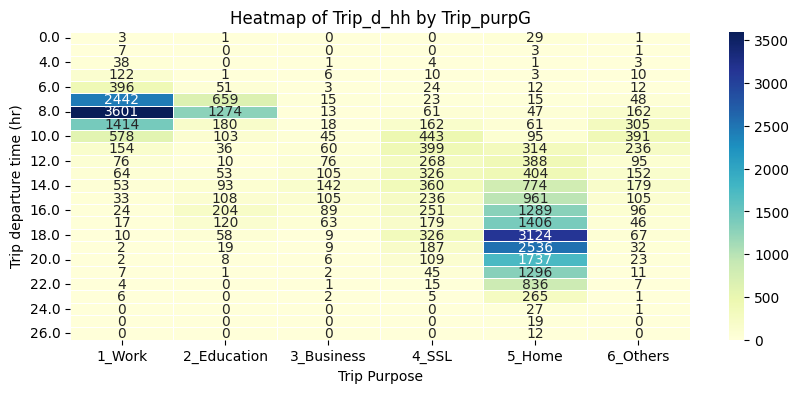

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(Tripdata)

a = df.pivot_table(index='Trip_time_D', columns='Trip_purpG', aggfunc='size', fill_value=0)

print(a)

# 히트맵
plt.figure(figsize=(10, 4))
sns.heatmap(a, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Heatmap of Trip_d_hh by Trip_purpG')
plt.xlabel('Trip Purpose')
plt.ylabel('Trip departure time (hr)')
plt.show()

- 오전 7-9시에 Work, Education을 위한 출발통행이 몰려있음
- 오후 4-9시(16-21시)에 Home을 위한 출발통행이 몰려있음

__도착시각(시)와 통행목적의 관계__

Trip_purpG   1_Work  2_Education  3_Business  4_SSL  5_Home  6_Others
Trip_time_A                                                          
0.0               3            1           0      0      26         1
1.0               0            0           0      0       3         0
3.0               5            0           0      0       3         1
4.0              24            0           1      2       1         2
5.0              77            0           3     11       2         6
6.0             209           11           3     22      11        10
7.0             864          350           5     19      16        35
8.0            4540         1426          17     56      41       137
9.0            2061          294          21    135      52       295
10.0            754          151          39    387      79       368
11.0            188           57          59    429     269       277
12.0             86           23          68    294     367       114
13.0             73 

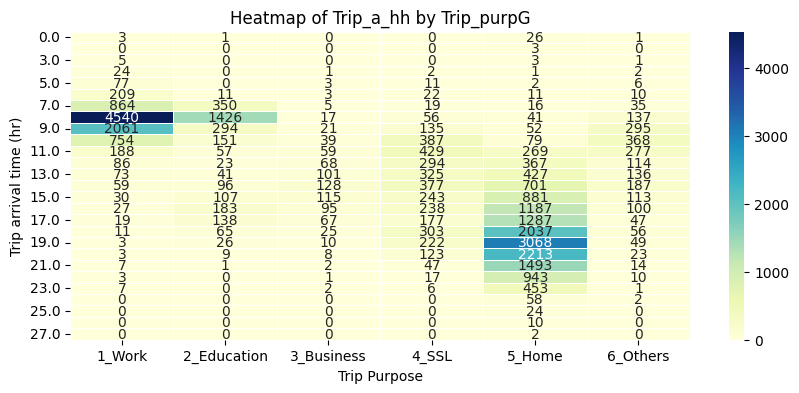

In [47]:
df = pd.DataFrame(Tripdata)

a = df.pivot_table(index='Trip_time_A', columns='Trip_purpG', aggfunc='size', fill_value=0)

print(a)

# 히트맵
plt.figure(figsize=(10, 4))
sns.heatmap(a, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Heatmap of Trip_a_hh by Trip_purpG')
plt.xlabel('Trip Purpose')
plt.ylabel('Trip arrival time (hr)')
plt.show()

- 오전 7-9시에 Work, Education의 도착통행이 몰려있음
- 오후 4-9시(16-21시)에 Home의 도착통행이 몰려있음

#### __출발시각/도착시각에 대한 변수 제작__

ver.1) 출발 시각과 도착 시각이 각각 오전 7-9시인지, 오후 4-9시(16-21시)인지 여부에 대한 변수 제작

In [48]:
# 오전 7-9시 출발 여부 (Work, Education을 위한 출발통행이 몰려있음)

def D_time_7to9(row):
    if ( 7 <= row['Trip_time_D'] <= 9):
        return 1    # 오전 7-9시 출발
    else:
        return 0

Tripdata['D_time_7to9'] = Tripdata.apply(lambda row: D_time_7to9(row), axis=1)

In [49]:
# 오후 4-9시(16-21시) 출발 여부 (Home을 위한 출발통행이 몰려있음)

def D_time_16to21(row):
    if ( 16 <= row['Trip_time_D'] <= 21):
        return 1    # 오후 4-9시(16-21시) 출발
    else:
        return 0

Tripdata['D_time_16to21'] = Tripdata.apply(lambda row: D_time_16to21(row), axis=1)

In [50]:
# 오전 7-9시 도착 여부 (Work, Education의 도착통행이 몰려있음)

def A_time_7to9(row):
    if ( 7 <= row['Trip_time_A'] <= 9):
        return 1    # 오전 7-9시 도착
    else:
        return 0

Tripdata['A_time_7to9'] = Tripdata.apply(lambda row: A_time_7to9(row), axis=1)

In [51]:
# 오후 4-9시(16-21시) 도착 여부 (Home의 도착통행이 몰려있음)

def A_time_16to21(row):
    if ( 16 <= row['Trip_time_A'] <= 21):
        return 1    # 오후 4-9시(16-21시) 도착
    else:
        return 0

Tripdata['A_time_16to21'] = Tripdata.apply(lambda row: A_time_16to21(row), axis=1)

ver.2) 출발 or 도착 시각 둘 중 하나가 오전 7-9시인지, 오후 4-9시(16-21시)인지 여부에 대한 변수 제작

In [52]:
# 오전 7-9시 출발 or 도착 여부 (Work, Education을 위한 출발통행이 몰려있음)

def DA_time_7to9(row):
    if (( 7 <= row['Trip_time_D'] <= 9) or ( 7 <= row['Trip_time_A'] <= 9)):
        return 1    # 오전 7-9시 출발 or 도착
    else:
        return 0

Tripdata['DA_time_7to9'] = Tripdata.apply(lambda row: DA_time_7to9(row), axis=1)

In [53]:
# 오후 4-9시(16-21시) 출발 or 도착 여부 (Home을 위한 출발통행이 몰려있음)

def DA_time_16to21(row):
    if (( 16 <= row['Trip_time_D'] <= 21) or ( 16 <= row['Trip_time_A'] <= 21)):
        return 1    # 오후 4-9시(16-21시) 출발 or 도착
    else:
        return 0

Tripdata['DA_time_16to21'] = Tripdata.apply(lambda row: DA_time_16to21(row), axis=1)

#### __출발지와 도착지 행정동 코드가 같은지 여부__

In [54]:
# 출발지와 도착지 행정동 코드가 같은지 여부

def DA_same(row):
    if ( row['Trip_d_D'] == row['Trip_a_D'] ):
        return 1
    else:
        return 0

Tripdata['DA_same'] = Tripdata.apply(lambda row: DA_same(row), axis=1)

__서울시 구코드 변수화 (출발지, 도착지 각각)__

- 이유: 목적지가 되는 구별로 통행 목적이 갈릴 수 있을 것이라 생각하였다. (ex. 업무시설이 많은 구역 -> '통근' 목적 통행이 많다)

1) 출발지 구코드

In [55]:
# 서울 구코드 변수화 (25개 구)

def D_jongro(row):
    if (1111000000 <= row['Trip_d_D'] < 1111100000):
        return 1    
    else:
        return 0    

def D_jung(row):
    if (1114000000 <= row['Trip_d_D'] < 1114100000):
        return 1    
    else:
        return 0

def D_yongsan(row):
    if (1117000000 <= row['Trip_d_D'] < 1117100000):
        return 1    
    else:
        return 0

def D_seongdong(row):
    if (1120000000 <= row['Trip_d_D'] < 1120100000):
        return 1    
    else:
        return 0

def D_gwangjin(row):
    if (1121500000 <= row['Trip_d_D'] < 1121600000):
        return 1    
    else:
        return 0    

def D_dongdaemun(row):
    if (1123000000 <= row['Trip_d_D'] < 1123100000):
        return 1    
    else:
        return 0    

def D_jungrang(row):
    if (1126000000 <= row['Trip_d_D'] < 1126100000):
        return 1    
    else:
        return 0

def D_seongbuk(row):
    if (1129000000 <= row['Trip_d_D'] < 1129100000):
        return 1    
    else:
        return 0

def D_gangbuk(row):
    if (1130500000 <= row['Trip_d_D'] < 1130600000):
        return 1    
    else:
        return 0

def D_dobong(row):
    if (1132000000 <= row['Trip_d_D'] < 1132100000):
        return 1    
    else:
        return 0 

def D_nowon(row):
    if (1135000000 <= row['Trip_d_D'] < 1135100000):
        return 1    
    else:
        return 0    

def D_eunpyung(row):
    if (1138000000 <= row['Trip_d_D'] < 1138100000):
        return 1    
    else:
        return 0

def D_seodaemun(row):
    if (1141000000 <= row['Trip_d_D'] < 1141100000):
        return 1    
    else:
        return 0

def D_mapo(row):
    if (1144000000 <= row['Trip_d_D'] < 1144100000):
        return 1    
    else:
        return 0

def D_yangcheon(row):
    if (1147000000 <= row['Trip_d_D'] < 1147100000):
        return 1    
    else:
        return 0    

def D_gangseo(row):
    if (1150000000 <= row['Trip_d_D'] < 1150100000):
        return 1    
    else:
        return 0    

def D_guro(row):
    if (1153000000 <= row['Trip_d_D'] < 1153100000):
        return 1    
    else:
        return 0

def D_geumcheon(row):
    if (1154500000 <= row['Trip_d_D'] < 1154600000):
        return 1    
    else:
        return 0

def D_yeongdeungpo(row):
    if (1156000000 <= row['Trip_d_D'] < 1156100000):
        return 1    
    else:
        return 0

def D_dongjak(row):
    if (1159000000 <= row['Trip_d_D'] < 1159100000):
        return 1    
    else:
        return 0  

def D_gwanak(row):
    if (1162000000 <= row['Trip_d_D'] < 1162100000):
        return 1    
    else:
        return 0

def D_seocho(row):
    if (1165000000 <= row['Trip_d_D'] < 1165100000):
        return 1    
    else:
        return 0

def D_gangnam(row):
    if (1168000000 <= row['Trip_d_D'] < 1168100000):
        return 1    
    else:
        return 0

def D_songpa(row):
    if (1171000000 <= row['Trip_d_D'] < 1171100000):
        return 1    
    else:
        return 0 

def D_gangdong(row):
    if (1174000000 <= row['Trip_d_D'] < 1174100000):
        return 1    
    else:
        return 0 

Tripdata['D_jongro'] = Tripdata.apply(lambda row: D_jongro(row), axis=1)
Tripdata['D_jung'] = Tripdata.apply(lambda row: D_jung(row), axis=1)
Tripdata['D_yongsan'] = Tripdata.apply(lambda row: D_yongsan(row), axis=1)
Tripdata['D_seongdong'] = Tripdata.apply(lambda row: D_seongdong(row), axis=1)
Tripdata['D_gwangjin'] = Tripdata.apply(lambda row: D_gwangjin(row), axis=1)
Tripdata['D_dongdaemun'] = Tripdata.apply(lambda row: D_dongdaemun(row), axis=1)
Tripdata['D_jungrang'] = Tripdata.apply(lambda row: D_jungrang(row), axis=1)
Tripdata['D_seongbuk'] = Tripdata.apply(lambda row: D_seongbuk(row), axis=1)
Tripdata['D_gangbuk'] = Tripdata.apply(lambda row: D_gangbuk(row), axis=1)
Tripdata['D_dobong'] = Tripdata.apply(lambda row: D_dobong(row), axis=1)
Tripdata['D_nowon'] = Tripdata.apply(lambda row: D_nowon(row), axis=1)
Tripdata['D_eunpyung'] = Tripdata.apply(lambda row: D_eunpyung(row), axis=1)
Tripdata['D_seodaemun'] = Tripdata.apply(lambda row: D_seodaemun(row), axis=1)
Tripdata['D_mapo'] = Tripdata.apply(lambda row: D_mapo(row), axis=1)
Tripdata['D_yangcheon'] = Tripdata.apply(lambda row: D_yangcheon(row), axis=1)
Tripdata['D_gangseo'] = Tripdata.apply(lambda row: D_gangseo(row), axis=1)
Tripdata['D_guro'] = Tripdata.apply(lambda row: D_guro(row), axis=1)
Tripdata['D_geumcheon'] = Tripdata.apply(lambda row: D_geumcheon(row), axis=1)
Tripdata['D_yeongdeungpo'] = Tripdata.apply(lambda row: D_yeongdeungpo(row), axis=1)
Tripdata['D_dongjak'] = Tripdata.apply(lambda row: D_dongjak(row), axis=1)
Tripdata['D_gwanak'] = Tripdata.apply(lambda row: D_gwanak(row), axis=1)
Tripdata['D_seocho'] = Tripdata.apply(lambda row: D_seocho(row), axis=1)
Tripdata['D_gangnam'] = Tripdata.apply(lambda row: D_gangnam(row), axis=1)
Tripdata['D_songpa'] = Tripdata.apply(lambda row: D_songpa(row), axis=1)
Tripdata['D_gangdong'] = Tripdata.apply(lambda row: D_gangdong(row), axis=1)

2) 도착지 구코드 (통행목적을 예측하는 데 출발지보다 유의미할 것으로 생각)

In [56]:
# 서울 구코드 변수화 (25개 구)

def A_jongro(row):
    if (1111000000 <= row['Trip_a_D'] < 1111100000):
        return 1    
    else:
        return 0    

def A_jung(row):
    if (1114000000 <= row['Trip_a_D'] < 1114100000):
        return 1    
    else:
        return 0

def A_yongsan(row):
    if (1117000000 <= row['Trip_a_D'] < 1117100000):
        return 1    
    else:
        return 0

def A_seongdong(row):
    if (1120000000 <= row['Trip_a_D'] < 1120100000):
        return 1    
    else:
        return 0

def A_gwangjin(row):
    if (1121500000 <= row['Trip_a_D'] < 1121600000):
        return 1    
    else:
        return 0    

def A_dongdaemun(row):
    if (1123000000 <= row['Trip_a_D'] < 1123100000):
        return 1    
    else:
        return 0    

def A_jungrang(row):
    if (1126000000 <= row['Trip_a_D'] < 1126100000):
        return 1    
    else:
        return 0

def A_seongbuk(row):
    if (1129000000 <= row['Trip_a_D'] < 1129100000):
        return 1    
    else:
        return 0

def A_gangbuk(row):
    if (1130500000 <= row['Trip_a_D'] < 1130600000):
        return 1    
    else:
        return 0

def A_dobong(row):
    if (1132000000 <= row['Trip_a_D'] < 1132100000):
        return 1    
    else:
        return 0 

def A_nowon(row):
    if (1135000000 <= row['Trip_a_D'] < 1135100000):
        return 1    
    else:
        return 0    

def A_eunpyung(row):
    if (1138000000 <= row['Trip_a_D'] < 1138100000):
        return 1    
    else:
        return 0

def A_seodaemun(row):
    if (1141000000 <= row['Trip_a_D'] < 1141100000):
        return 1    
    else:
        return 0

def A_mapo(row):
    if (1144000000 <= row['Trip_a_D'] < 1144100000):
        return 1    
    else:
        return 0

def A_yangcheon(row):
    if (1147000000 <= row['Trip_a_D'] < 1147100000):
        return 1    
    else:
        return 0    

def A_gangseo(row):
    if (1150000000 <= row['Trip_a_D'] < 1150100000):
        return 1    
    else:
        return 0    

def A_guro(row):
    if (1153000000 <= row['Trip_a_D'] < 1153100000):
        return 1    
    else:
        return 0

def A_geumcheon(row):
    if (1154500000 <= row['Trip_a_D'] < 1154600000):
        return 1    
    else:
        return 0

def A_yeongdeungpo(row):
    if (1156000000 <= row['Trip_a_D'] < 1156100000):
        return 1    
    else:
        return 0

def A_dongjak(row):
    if (1159000000 <= row['Trip_a_D'] < 1159100000):
        return 1    
    else:
        return 0  

def A_gwanak(row):
    if (1162000000 <= row['Trip_a_D'] < 1162100000):
        return 1    
    else:
        return 0

def A_seocho(row):
    if (1165000000 <= row['Trip_a_D'] < 1165100000):
        return 1    
    else:
        return 0

def A_gangnam(row):
    if (1168000000 <= row['Trip_a_D'] < 1168100000):
        return 1    
    else:
        return 0

def A_songpa(row):
    if (1171000000 <= row['Trip_a_D'] < 1171100000):
        return 1    
    else:
        return 0 

def A_gangdong(row):
    if (1174000000 <= row['Trip_a_D'] < 1174100000):
        return 1    
    else:
        return 0 

Tripdata['A_jongro'] = Tripdata.apply(lambda row: A_jongro(row), axis=1)
Tripdata['A_jung'] = Tripdata.apply(lambda row: A_jung(row), axis=1)
Tripdata['A_yongsan'] = Tripdata.apply(lambda row: A_yongsan(row), axis=1)
Tripdata['A_seongdong'] = Tripdata.apply(lambda row: A_seongdong(row), axis=1)
Tripdata['A_gwangjin'] = Tripdata.apply(lambda row: A_gwangjin(row), axis=1)
Tripdata['A_dongdaemun'] = Tripdata.apply(lambda row: A_dongdaemun(row), axis=1)
Tripdata['A_jungrang'] = Tripdata.apply(lambda row: A_jungrang(row), axis=1)
Tripdata['A_seongbuk'] = Tripdata.apply(lambda row: A_seongbuk(row), axis=1)
Tripdata['A_gangbuk'] = Tripdata.apply(lambda row: A_gangbuk(row), axis=1)
Tripdata['A_dobong'] = Tripdata.apply(lambda row: A_dobong(row), axis=1)
Tripdata['A_nowon'] = Tripdata.apply(lambda row: A_nowon(row), axis=1)
Tripdata['A_eunpyung'] = Tripdata.apply(lambda row: A_eunpyung(row), axis=1)
Tripdata['A_seodaemun'] = Tripdata.apply(lambda row: A_seodaemun(row), axis=1)
Tripdata['A_mapo'] = Tripdata.apply(lambda row: A_mapo(row), axis=1)
Tripdata['A_yangcheon'] = Tripdata.apply(lambda row: A_yangcheon(row), axis=1)
Tripdata['A_gangseo'] = Tripdata.apply(lambda row: A_gangseo(row), axis=1)
Tripdata['A_guro'] = Tripdata.apply(lambda row: A_guro(row), axis=1)
Tripdata['A_geumcheon'] = Tripdata.apply(lambda row: A_geumcheon(row), axis=1)
Tripdata['A_yeongdeungpo'] = Tripdata.apply(lambda row: A_yeongdeungpo(row), axis=1)
Tripdata['A_dongjak'] = Tripdata.apply(lambda row: A_dongjak(row), axis=1)
Tripdata['A_gwanak'] = Tripdata.apply(lambda row: A_gwanak(row), axis=1)
Tripdata['A_seocho'] = Tripdata.apply(lambda row: A_seocho(row), axis=1)
Tripdata['A_gangnam'] = Tripdata.apply(lambda row: A_gangnam(row), axis=1)
Tripdata['A_songpa'] = Tripdata.apply(lambda row: A_songpa(row), axis=1)
Tripdata['A_gangdong'] = Tripdata.apply(lambda row: A_gangdong(row), axis=1)

__변수 설명) 출발지의 타입별(4가지) 빈도수가 높게 등장하는 행정동 확인__

- Home이 목적지인 통행이 많은 행정동: 거주의 특성이 뚜렷할 것
- Office가 목적지인 통행이 많은 행정동: 상업용 건물이 많을 것
- School가 목적지인 통행이 많은 행정동: 학교가 많을 것이라 예상할 수 있다.

In [58]:
# Trip_a_ty = 1 (Home)
result = Tripdata.groupby('행정동_A')['Trip_a_ty'].value_counts().unstack(fill_value=0)

result = result.sort_values(by=1, ascending=False)

result.describe()

Trip_a_ty,1.0,2.0,3.0,4.0
count,634.000000,634.000000,634.000000,634.000000
mean,24.690852,14.940063,3.585174,10.211356
std,77.165007,35.781188,11.753518,28.931353
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000
50%,0.000000,3.000000,0.000000,1.000000
75%,0.000000,8.000000,1.000000,3.000000
max,563.000000,368.000000,129.000000,201.000000


In [59]:
result.head(5)

Trip_a_ty,1.0,2.0,3.0,4.0
행정동_A,,,,
창신제3동,563,17,31,23
성산2동,553,153,41,201
불광1동,521,145,35,130
남가좌2동,399,44,80,97
녹번동,379,101,21,77


In [61]:
# Trip_a_ty = 2 (Office)
result = Tripdata.groupby('행정동_A')['Trip_a_ty'].value_counts().unstack(fill_value=0)

result = result.sort_values(by=2, ascending=False)

result.head(5)

Trip_a_ty,1.0,2.0,3.0,4.0
행정동_A,,,,
종로1·2·3·4가동,56,368,3,159
서교동,285,291,3,168
명동,68,243,6,122
아현동,330,193,5,103
신촌동,209,170,129,198


In [62]:
# Trip_a_ty = 3 (School)
result = Tripdata.groupby('행정동_A')['Trip_a_ty'].value_counts().unstack(fill_value=0)

result = result.sort_values(by=3, ascending=False)

result.head(5)

Trip_a_ty,1.0,2.0,3.0,4.0
행정동_A,,,,
신촌동,209,170,129,198
홍은2동,237,60,84,81
남가좌2동,399,44,80,97
혜화동,373,57,75,98
구산동,300,92,70,59


#### __Trip_a_ty별 순위권에 있는 행정동에 대해 변수 제작__

In [63]:
# 도착지로서의 목적이 Trip_a_ty = 1 (Home)이 많은 행정동

def A_Home(row):
    if ( row['행정동_A'] in ['창신제3동', '성산2동', '불광1동', '남가좌2동', '녹번동', '혜화동', '연희동', '진관동', '홍제3동', '아현동']):
        return 1
    else:
        return 0

Tripdata['A_Home'] = Tripdata.apply(lambda row: A_Home(row), axis=1)

In [64]:
# 도착지로서의 목적이 Trip_a_ty = 2 (Office)이 많은 행정동

def A_Office(row):
    if ( row['행정동_A'] in ['종로1·2·3·4가동', '서교동', '명동', '아현동', '신촌동', '여의동', '황학동', '성산2동', '신당동', '불광1동']):
        return 1
    else:
        return 0

Tripdata['A_Office'] = Tripdata.apply(lambda row: A_Office(row), axis=1)

# __'Navi Data' 변수 제작__

+) decision tree 모델에 적용할 수 있게 변수 이름 통일

__참고자료: KOSIS 통계청 코드와 행정안전부 코드 연계표__

In [66]:
Transfer_Code = pd.read_csv('Code_transfer.csv')
Transfer_Code

,번호,행정안전부 코드,Unnamed: 2,한글명,레벨,통계청 코드,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,구코드:7자리,신코드:8자리,신코드:8자리.1
0,NaN,코드1\n(KOSIS DB코드),코드2\n(10자리),NaN,NaN,1998.0,1999.0,2000.0,2001.0,2002.0,...,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2022.0,2023.0
1,1.0,11,1100000000,서울특별시,시도,1100000.0,1100000.0,1100000.0,1100000.0,1100000.0,...,1100000.0,1100000.0,1100000.0,1100000.0,1100000.0,1100000.0,1100000.0,1100000.0,11000000.0,11000000.0
2,2.0,11110,1111000000,종로구,시군구,1101000.0,1101000.0,1101000.0,1101000.0,1101000.0,...,1101000.0,1101000.0,1101000.0,1101000.0,1101000.0,1101000.0,1101000.0,1101000.0,11010000.0,11010000.0
3,3.0,1111051000,1111051000,청운동,읍면동,1101051.0,1101051.0,1101051.0,1101051.0,1101051.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.0,1111051500,1111051500,청운효자동,읍면동,NaN,NaN,NaN,NaN,NaN,...,1101072.0,1101072.0,1101072.0,1101072.0,1101072.0,1101072.0,1101072.0,1101072.0,11010720.0,11010720.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4872,4872.0,5013058000,5013058000,서홍동,읍면동,NaN,NaN,NaN,NaN,NaN,...,3902058.0,3902058.0,3902058.0,3902058.0,3902058.0,3902058.0,3902058.0,3902058.0,39020580.0,39020580.0
4873,4873.0,5013059000,5013059000,대륜동,읍면동,NaN,NaN,NaN,NaN,NaN,...,3902059.0,3902059.0,3902059.0,3902059.0,3902059.0,3902059.0,3902059.0,3902059.0,39020590.0,39020590.0
4874,4874.0,5013060000,5013060000,대천동,읍면동,NaN,NaN,NaN,NaN,NaN,...,3902060.0,3902060.0,3902060.0,3902060.0,3902060.0,3902060.0,3902060.0,3902060.0,39020600.0,39020600.0
4875,4875.0,5013061000,5013061000,중문동,읍면동,NaN,NaN,NaN,NaN,NaN,...,3902061.0,3902061.0,3902061.0,3902061.0,3902061.0,3902061.0,3902061.0,3902061.0,39020610.0,39020610.0


연계표 설명)
- 통계청 코드(총 8자리): 시도(2자리), 시군구(3자리), 읍면동(3자리) (2022~)
- 행정안전부 코드(총 10자리): 시도(2자리), 시군구(3자리), 읍면동(5자리)

In [68]:
# 서울 출발 여부

def D_seoul(row):
    if (row['ADM_CD_O'][:2] == '11'):
        return 1    # 서울 출발 (11로 동코드 시작)
    else:
        return 0    # 비서울 출발

NaviData_ADM['D_seoul'] = NaviData_ADM.apply(lambda row: D_seoul(row), axis=1)

In [69]:
# 서울 도착 여부

def A_seoul(row):
    if (row['ADM_CD_D'][:2] == '11'):
        return 1    # 서울 도착
    else:
        return 0    # 비서울 도착

NaviData_ADM['A_seoul'] = NaviData_ADM.apply(lambda row: A_seoul(row), axis=1)

In [70]:
# 서울 구코드 변수화 (25개 구) - 도착지
## "./BND_ADM_DONG_PG/BND_ADM_DONG_PG.shp" 파일에 맞추어 2023년 기준 통계청 코드를 사용하였다.

def A_jongro(row):
    if (row['ADM_CD_D'][:5] == '11010'):
        return 1    
    else:
        return 0    

def A_jung(row):
    if (row['ADM_CD_D'][:5] == '11020'):
        return 1    
    else:
        return 0

def A_yongsan(row):
    if (row['ADM_CD_D'][:5] == '11030'):
        return 1    
    else:
        return 0

def A_seongdong(row):
    if (row['ADM_CD_D'][:5] == '11040'):
        return 1    
    else:
        return 0

def A_gwangjin(row):
    if (row['ADM_CD_D'][:5] == '11050'):
        return 1    
    else:
        return 0    

def A_dongdaemun(row):
    if (row['ADM_CD_D'][:5] == '11060'):
        return 1    
    else:
        return 0    

def A_jungrang(row):
    if (row['ADM_CD_D'][:5] == '11070'):
        return 1    
    else:
        return 0

def A_seongbuk(row):
    if (row['ADM_CD_D'][:5] == '11080'):
        return 1    
    else:
        return 0

def A_gangbuk(row):
    if (row['ADM_CD_D'][:5] == '11090'):
        return 1    
    else:
        return 0

def A_dobong(row):
    if (row['ADM_CD_D'][:5] == '11100'):
        return 1    
    else:
        return 0 

def A_nowon(row):
    if (row['ADM_CD_D'][:5] == '11110'):
        return 1    
    else:
        return 0    

def A_eunpyung(row):
    if (row['ADM_CD_D'][:5] == '11120'):
        return 1    
    else:
        return 0

def A_seodaemun(row):
    if (row['ADM_CD_D'][:5] == '11130'):
        return 1    
    else:
        return 0

def A_mapo(row):
    if (row['ADM_CD_D'][:5] == '11140'):
        return 1    
    else:
        return 0

def A_yangcheon(row):
    if (row['ADM_CD_D'][:5] == '11150'):
        return 1    
    else:
        return 0    

def A_gangseo(row):
    if (row['ADM_CD_D'][:5] == '11160'):
        return 1    
    else:
        return 0    

def A_guro(row):
    if (row['ADM_CD_D'][:5] == '11170'):
        return 1    
    else:
        return 0

def A_geumcheon(row):
    if (row['ADM_CD_D'][:5] == '11180'):
        return 1    
    else:
        return 0

def A_yeongdeungpo(row):
    if (row['ADM_CD_D'][:5] == '11190'):
        return 1    
    else:
        return 0

def A_dongjak(row):
    if (row['ADM_CD_D'][:5] == '11200'):
        return 1    
    else:
        return 0  

def A_gwanak(row):
    if (row['ADM_CD_D'][:5] == '11210'):
        return 1    
    else:
        return 0

def A_seocho(row):
    if (row['ADM_CD_D'][:5] == '11220'):
        return 1    
    else:
        return 0

def A_gangnam(row):
    if (row['ADM_CD_D'][:5] == '11230'):
        return 1    
    else:
        return 0

def A_songpa(row):
    if (row['ADM_CD_D'][:5] == '11240'):
        return 1    
    else:
        return 0 

def A_gangdong(row):
    if (row['ADM_CD_D'][:5] == '11250'):
        return 1    
    else:
        return 0 

NaviData_ADM['A_jongro'] = NaviData_ADM.apply(lambda row: A_jongro(row), axis=1)
NaviData_ADM['A_jung'] = NaviData_ADM.apply(lambda row: A_jung(row), axis=1)
NaviData_ADM['A_yongsan'] = NaviData_ADM.apply(lambda row: A_yongsan(row), axis=1)
NaviData_ADM['A_seongdong'] = NaviData_ADM.apply(lambda row: A_seongdong(row), axis=1)
NaviData_ADM['A_gwangjin'] = NaviData_ADM.apply(lambda row: A_gwangjin(row), axis=1)
NaviData_ADM['A_dongdaemun'] = NaviData_ADM.apply(lambda row: A_dongdaemun(row), axis=1)
NaviData_ADM['A_jungrang'] = NaviData_ADM.apply(lambda row: A_jungrang(row), axis=1)
NaviData_ADM['A_seongbuk'] = NaviData_ADM.apply(lambda row: A_seongbuk(row), axis=1)
NaviData_ADM['A_gangbuk'] = NaviData_ADM.apply(lambda row: A_gangbuk(row), axis=1)
NaviData_ADM['A_dobong'] = NaviData_ADM.apply(lambda row: A_dobong(row), axis=1)
NaviData_ADM['A_nowon'] = NaviData_ADM.apply(lambda row: A_nowon(row), axis=1)
NaviData_ADM['A_eunpyung'] = NaviData_ADM.apply(lambda row: A_eunpyung(row), axis=1)
NaviData_ADM['A_seodaemun'] = NaviData_ADM.apply(lambda row: A_seodaemun(row), axis=1)
NaviData_ADM['A_mapo'] = NaviData_ADM.apply(lambda row: A_mapo(row), axis=1)
NaviData_ADM['A_yangcheon'] = NaviData_ADM.apply(lambda row: A_yangcheon(row), axis=1)
NaviData_ADM['A_gangseo'] = NaviData_ADM.apply(lambda row: A_gangseo(row), axis=1)
NaviData_ADM['A_guro'] = NaviData_ADM.apply(lambda row: A_guro(row), axis=1)
NaviData_ADM['A_geumcheon'] = NaviData_ADM.apply(lambda row: A_geumcheon(row), axis=1)
NaviData_ADM['A_yeongdeungpo'] = NaviData_ADM.apply(lambda row: A_yeongdeungpo(row), axis=1)
NaviData_ADM['A_dongjak'] = NaviData_ADM.apply(lambda row: A_dongjak(row), axis=1)
NaviData_ADM['A_gwanak'] = NaviData_ADM.apply(lambda row: A_gwanak(row), axis=1)
NaviData_ADM['A_seocho'] = NaviData_ADM.apply(lambda row: A_seocho(row), axis=1)
NaviData_ADM['A_gangnam'] = NaviData_ADM.apply(lambda row: A_gangnam(row), axis=1)
NaviData_ADM['A_songpa'] = NaviData_ADM.apply(lambda row: A_songpa(row), axis=1)
NaviData_ADM['A_gangdong'] = NaviData_ADM.apply(lambda row: A_gangdong(row), axis=1)

In [71]:
# 오전 7-9시 출발 or 도착 여부 (Work, Education을 위한 출발통행이 몰려있음)

def DA_time_7to9(row):
    if (( 7 <= row['Time_H_O'] <= 9) or ( 7 <= row['Time_H_D'] <= 9)):
        return 1    # 오전 7-9시 출발 or 도착
    else:
        return 0

NaviData_ADM['DA_time_7to9'] = NaviData_ADM.apply(lambda row: DA_time_7to9(row), axis=1)

In [72]:
# 오후 4-9시(16-21시) 출발 or 도착 여부 (Home을 위한 출발통행이 몰려있음)

def DA_time_16to21(row):
    if (( 16 <= row['Time_H_O'] <= 21) or ( 16 <= row['Time_H_D'] <= 21)):
        return 1    # 오후 4-9시(16-21시) 출발 or 도착
    else:
        return 0

NaviData_ADM['DA_time_16to21'] = NaviData_ADM.apply(lambda row: DA_time_16to21(row), axis=1)

열 이름 통일

In [81]:
NaviData_ADM.rename(columns={
    'Time_H_O': 'Trip_time_D',
    'Time_H_D': 'Trip_time_A',
    'TripID': 'Trip_ID',
    'T_time': 'Trip_time'}, inplace=True)

In [82]:
NaviData_ADM

,ID,Date,Trip_ID,Longitude_O,Latitude_O,Trip_time_D,Longitude_D,Latitude_D,Trip_time_A,Trip_time,...,A_geumcheon,A_yeongdeungpo,A_dongjak,A_gwanak,A_seocho,A_gangnam,A_songpa,A_gangdong,DA_time_7to9,DA_time_16to21
0,502915,20171209,1,126.888421,37.510334,12.425833,126.853681,37.527005,12.979167,33.200000,...,0,0,0,0,0,0,0,0,0,0
1,502915,20171209,2,126.853612,37.526708,18.477222,126.887373,37.509903,18.878333,24.066667,...,0,0,0,0,0,0,0,0,0,1
2,567810,20171209,1,126.759338,37.893490,14.844722,127.003283,37.581771,16.812778,118.083333,...,0,0,0,0,0,0,0,0,0,1
3,567810,20171209,2,127.003075,37.579635,19.860278,126.760288,37.894524,21.171111,78.650000,...,0,0,0,0,0,0,0,0,0,1
4,600415,20171223,1,127.276707,38.092911,15.976944,127.054269,37.891739,16.906944,55.800000,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6028,3088962,20171211,4,127.079313,37.794664,14.550833,127.040097,37.907772,14.688056,8.233333,...,0,0,0,0,0,0,0,0,0,0
6029,3095826,20171228,1,127.351348,37.885981,8.930278,127.351503,37.885670,9.024722,5.666667,...,0,0,0,0,0,0,0,0,1,0
6030,3103978,20171217,3,127.275154,38.087547,21.260000,127.275154,38.087547,23.993333,164.000000,...,0,0,0,0,0,0,0,0,0,0
6031,3103978,20171219,1,127.274871,38.087522,0.008056,127.266132,38.091824,1.348889,80.450000,...,0,0,0,0,0,0,0,0,0,0


In [83]:
NaviData_ADM.columns

Index(['ID', 'Date', 'Trip_ID', 'Longitude_O', 'Latitude_O', 'Trip_time_D',
       'Longitude_D', 'Latitude_D', 'Trip_time_A', 'Trip_time', 'ADM_CD_O',
       'ADM_NM_O', 'ADM_CD_D', 'ADM_NM_D', 'D_seoul', 'A_seoul', 'A_jongro',
       'A_jung', 'A_yongsan', 'A_seongdong', 'A_gwangjin', 'A_dongdaemun',
       'A_jungrang', 'A_seongbuk', 'A_gangbuk', 'A_dobong', 'A_nowon',
       'A_eunpyung', 'A_seodaemun', 'A_mapo', 'A_yangcheon', 'A_gangseo',
       'A_guro', 'A_geumcheon', 'A_yeongdeungpo', 'A_dongjak', 'A_gwanak',
       'A_seocho', 'A_gangnam', 'A_songpa', 'A_gangdong', 'DA_time_7to9',
       'DA_time_16to21'],
      dtype='object')

In [139]:
# 모델에 넣을 변수(열)만 고르기
NaviData_ADM2 = NaviData_ADM[['Trip_ID', 'D_seoul','A_seoul', 'Trip_time', 'Trip_time_D','Trip_time_A', 'DA_time_7to9','DA_time_16to21',
'A_jongro','A_jung','A_yongsan','A_seongdong','A_gwangjin','A_dongdaemun','A_jungrang','A_seongbuk','A_gangbuk','A_dobong','A_nowon','A_eunpyung','A_seodaemun','A_mapo','A_yangcheon','A_gangseo','A_guro','A_geumcheon','A_yeongdeungpo','A_dongjak','A_gwanak','A_seocho','A_gangnam','A_songpa','A_gangdong']]

In [87]:
NaviData_ADM2

,Trip_ID,D_seoul,A_seoul,Trip_time,Trip_time_D,Trip_time_A,DA_time_7to9,DA_time_16to21,A_jongro,A_jung,...,A_gangseo,A_guro,A_geumcheon,A_yeongdeungpo,A_dongjak,A_gwanak,A_seocho,A_gangnam,A_songpa,A_gangdong
0,1,1,1,33.200000,12.425833,12.979167,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,24.066667,18.477222,18.878333,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
2,1,0,1,118.083333,14.844722,16.812778,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2,1,0,78.650000,19.860278,21.171111,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,55.800000,15.976944,16.906944,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6028,4,0,0,8.233333,14.550833,14.688056,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6029,1,0,0,5.666667,8.930278,9.024722,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6030,3,0,0,164.000000,21.260000,23.993333,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6031,1,0,0,80.450000,0.008056,1.348889,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# __Decision tree__

__변수 설명__
1) 포함
- 'Trip_ID': 몇 번째 통행인지
- 'D_seoul','A_seoul': 출발지/도착지가 서울인지 아닌지
- 'Trip_time': 통행 시간(분 단위)
- 'Trip_time_D','Trip_time_A': 출발/도착의 시각(시)
- 'DA_time_7to9','DA_time_16to21': 출발, 도착 시각이 각각 7-9시, 16-21시인지에 대한 변수보다는 출발과 도착을 "묶어", 둘 중 하나라도 해당 시간대에 속하는지에 대한 변수가 더 유의미했다.
- 'A_jongro','A_jung','A_yongsan', ...: 그에 반해 도착지 구코드는 정확도를 유의미하게 높였다.
2) 제외
- 'D_time_7to9','D_time_16to21','A_time_7to9','A_time_16to21': 출발과 도착 시각을 묶어서 사용한 변수가 더 유의미했다.
- 'D_jongro','D_jung','D_yongsan', ...: 출발지 구코드는 정확도를 낮추었다. 통행목적과 출발지 구코드는 큰 관련이 없어보인다.
- 'A_Home', 'A_Office': 'Trip_a_ty'를 활용해 도착지로서의 통행의 목적이 '집', 'office', 'school'으로 나타나는 빈도가 많은 행정동인지를 변수화해서 넣어보았지만, 10개 남짓을 넣었을 때는 정확도가 오히려 떨어졌다. 하지만 분명 유의미한 변수로 생각되며, 정확도가 떨어진 이유는 10위 이상의 더 많은 행정동을 넣지 못해서라고 예측한다.

In [125]:
from sklearn.model_selection import train_test_split
from sklearn import tree

X=Tripdata[['Trip_ID','D_seoul','A_seoul','Trip_time','Trip_time_D','Trip_time_A',
            'DA_time_7to9','DA_time_16to21',
           'A_jongro','A_jung','A_yongsan','A_seongdong','A_gwangjin','A_dongdaemun','A_jungrang','A_seongbuk','A_gangbuk','A_dobong','A_nowon','A_eunpyung','A_seodaemun','A_mapo','A_yangcheon','A_gangseo','A_guro','A_geumcheon','A_yeongdeungpo','A_dongjak','A_gwanak','A_seocho','A_gangnam','A_songpa','A_gangdong']]
y=Tripdata['Trip_purpG']

In [126]:
import numpy as np
Max_depth = 30
f1_result=pd.DataFrame(np.zeros([Max_depth,2])).rename(columns={0:"Train_data",1:"Test_data"})

In [127]:
for i in range (1,Max_depth+1):
    DT_Purp=tree.DecisionTreeClassifier(criterion='entropy', max_depth=i, random_state=1)
    DT_Purp.fit(X_train, y_train)
    y_train_pred = DT_Purp.predict(X_train)
    y_test_pred = DT_Purp.predict(X_test)
    
    f1_result.loc[i-1,"Train_data"]=f1_score(y_train, y_train_pred, average='weighted')
    f1_result.loc[i-1,"Test_data"]=f1_score(y_test, y_test_pred, average='weighted')

In [128]:
f1_result

,Train_data,Test_data
0,0.616963,0.617359
1,0.679496,0.682161
2,0.676786,0.682552
3,0.676786,0.682552
4,0.692265,0.697743
5,0.706552,0.712515
6,0.713334,0.714824
7,0.740226,0.738665
8,0.745443,0.736425
9,0.755020,0.737092


Random forest로 더 낮은 score만 얻을 수 있었으며, 위와 같은 방법으로 가장 높은 score가 나오는 depth를 찾아 사용하였다.

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                   test_size=0.1,
                                                   random_state=0,
                                                    stratify=y)

DT_Purp=tree.DecisionTreeClassifier(criterion='gini', max_depth=11, random_state=1)
DT_Purp.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=11, random_state=1)

In [130]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = DT_Purp.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 750   91    1   36   10   18]
 [ 117  120    1    8   49    3]
 [   5    7   24    3   35    3]
 [  53   13    9  161   97   10]
 [   0   15   15    4 1531    1]
 [  61   17    9   59   37   15]]
              precision    recall  f1-score   support

      1_Work       0.76      0.83      0.79       906
 2_Education       0.46      0.40      0.43       298
  3_Business       0.41      0.31      0.35        77
       4_SSL       0.59      0.47      0.52       343
      5_Home       0.87      0.98      0.92      1566
    6_Others       0.30      0.08      0.12       198

    accuracy                           0.77      3388
   macro avg       0.56      0.51      0.52      3388
weighted avg       0.73      0.77      0.74      3388



In [131]:
from sklearn.metrics import f1_score
f1_score(y_test, y_pred, average='weighted')

0.7434813022705885

__최종 score: 0.7434813022705885__

### __내비게이션 자료 통행 예측__

In [132]:
# 예측 수행
y_pred_Navi = DT_Purp.predict(NaviData_ADM2)

pred_df = pd.DataFrame({'Predicted': y_pred_Navi})
trip_counts = pred_df['Predicted'].value_counts()
total_trips = trip_counts.sum()

# 분담률 계산
trip_shares = (trip_counts / total_trips) * 100


result_df = pd.DataFrame({'통행수': trip_counts, '분담률(%)': trip_shares})
print(result_df)

              통행수     분담률(%)
Predicted                   
5_Home       1980  32.819493
1_Work       1342  22.244323
3_Business   1135  18.813194
4_SSL        1095  18.150174
6_Others      406   6.729654
2_Education    75   1.243163


In [ ]:
# 통행 수 총합: 6033

__오버피팅 여부 확인__

In [138]:
# 훈련 데이터에 대한 예측 및 F1 스코어 계산
y_train_pred = DT_Purp.predict(X_train)
f1_train = f1_score(y_train, y_train_pred, average='weighted')

# 테스트 데이터에 대한 예측 및 F1 스코어 계산
y_test_pred = DT_Purp.predict(X_test)
f1_test = f1_score(y_test, y_test_pred, average='weighted')

# F1 스코어 출력
print(f'F1 Score on Training Data: {f1_train}')
print(f'F1 Score on Test Data: {f1_test}')

# 오버피팅 여부 확인
if f1_train / f1_test >= 1.3:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")

F1 Score on Training Data: 0.7658909461108936
F1 Score on Test Data: 0.7434813022705885
The model is not overfitting.
